## Introduction

In this notebook, we will do hands-on on what we learned in our reading material about the autoencoders. In particular, we will implement a simple denoising autoencoder using the `Keras library`.

## Motivation

You may be wondering why we are implementing denoising autoencoder. What are its' real-world applications? We will figure it out here.

Like we said before, the main purpose of the denoising autoencoder is to remove noise from the image while reconstructing the image. Suppose, in rainy season, you have to take photographs of the nature, living creatures, your friends, etc. Suppose there is slightly rain drops continuously falling on the camera lens, the taken photographs will be blurry one, right? That means, those rain drops on the lens added the noise in the images. How can you get not blurry images then?

<!-- <center>
<figure>
<img src="https://docs.google.com/uc?export=download&id=1fKf-WeMCT0mzdopHQlEhtIOC_3zQ3Uv6" alt="Vanilla Autoencoder" height=250 width=350>
<img src="https://docs.google.com/uc?export=download&id=1GzoEOEyZCqAxnROJ2z1VY1zoj8OKjg6P" alt="Vanilla Autoencoder" height=250 width=350>
<figcaption align="center">Figure 1: Right side of photograph taken from the left side camera during the raining season</figcaption>
</figure>
</center> -->
<center>
<figure>
<img src="https://i.postimg.cc/QtDVxx7K/image.png" alt="Vanilla Autoencoder" height=250 width=350>
<img src="https://i.postimg.cc/SNVycfMs/image.png" alt="Vanilla Autoencoder" height=250 width=350>
<figcaption align="center">Figure 1: Right side of photograph taken from the left side camera during the raining season</figcaption>
</figure>
</center>
One way to get not blurry images is to retake the photographs by cleaning the lens of the camera. That's obivious, right? The another one is to use the denoising autoencoder to reconstruct that blurry or noisy image. If you can reconstruct the image by removing the noise from the image then why do you retake photographs again and again by cleaning the lens.

So, you get the idea where we can use the denoising autoencoder.

## Dataset description

We will use `fashion MNIST dataset` for this implementation.

## Implementation

Now, let's implement denoising autoencoder using simple neural network.

## Load dataset

Now, we will load the dataset and add noise because we are going to implement the denoising autoencoder. For this, we need noisy dataset.

In [ ]:
# Importing fashion_mnist dataset
from keras.datasets import fashion_mnist

Using TensorFlow backend.


In [ ]:
# Loading fashion mnist dataset
(X_train, _), (X_test, _) = fashion_mnist.load_data()

4423680/4422102 [==============================] - 2s 0us/step


In [ ]:
X_train.shape

(60000, 28, 28)

There are 60000 images in the training set with image size of 28x28 dimension each. Each image is represented as the array of pixel value whose range is from 0 to 255. 0 refering to the black pixel and 255 represents the white one.

Therefore, we are normalizing the pixel values by dividing 255 to 0 to 1.

In [ ]:
# Normalizing the pixel values
X_train = X_train.astype('float32')/255 # For train set
X_test = X_test.astype('float32')/255 # For test set

## Adding noise

Since we are going to implement the denoising autoencoder, we should have data with noise. Since the original images don't contain any noise, we are manually adding noise to the original training and testing set.

In [ ]:
import numpy as np

noise_factor = 0.4

# Storing sizes, H and W of train set, train set, and image
TRAIN_SIZE = X_train.shape
TEST_SIZE = X_test.shape
H = X_train.shape[1]
W = X_train.shape[-1]

# Adding noise in train and test set with noise factor 0.4
X_train_noise = X_train + noise_factor * \
                  np.random.normal(loc=0, scale=1, size=TRAIN_SIZE)
X_test_noise = X_test + noise_factor * \
                  np.random.normal(loc=0, scale=1, size=TEST_SIZE)

# Clipping noisy train set and test set to 0 to 1
X_train_noise = np.clip(X_train_noise, 0., 1.)
X_test_noise = np.clip(X_test_noise, 0., 1.)

In the above cell, we are adding gaussina blur noise with standard size of gaussian blur ($\mu=0$, $\sigma=1$).

After that, we are multiplying this gaussian noise with noise factor. Here, noise factor gives how much noise we are adding to the original image. It means, if noise factor is 0.5, then, we are adding 50% of gaussian noise to the original images.

And finally we are clipping the noisy data out of range between 0 and 1.

In [ ]:
import matplotlib.pyplot as plt

def plot_images(N=0, image_array=None, reshape=False):
  # Number of image to show

  plt.figure(figsize=(20, 2))

  for i in range(N):
    image = image_array[i]
    ax = plt.subplot(1, N, i+1)
    if reshape:
      image = image_array[i].reshape(H, W)
    plt.imshow(image)
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
  plt.show()

 Oringial images


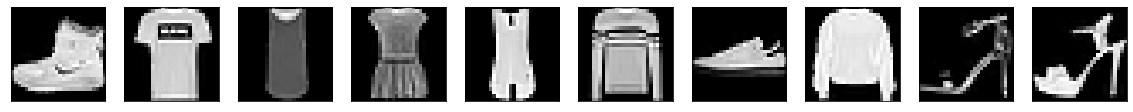

 Images after adding noise


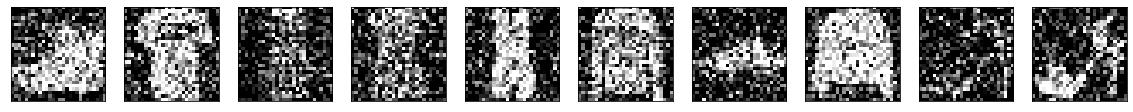

In [ ]:
print(" Oringial images\n","="*16)
plot_images(N=10, image_array=X_train)
print(" Images after adding noise\n","="*26)
plot_images(N=10, image_array=X_train_noise)

## Building a model

Now, let's build the simple deep neural network model for autoencoder.

We have our images in `row x H x W` format. We need to reshape this size to `row x d` format because the input layer needs 1D input data. Here, `d` represents `HxW`.

Our train set has `60000x28x28` dimension overall. Then, we first convert `28x28` into `784`. Then, reshaping `60000x28x28` to `60000x784`.

In [ ]:
# Converting HxW (2D dimension) into d (1D dimension)
# Multiplying 28x28 into 784
TRAIN_SIZE_PROD = np.prod(X_train.shape[1:])
TRAIN_NOISE_SIZE_PROD = np.prod(X_train_noise.shape[1:])
TEST_SIZE_PROD = np.prod(X_test.shape[1:])
TEST_NOISE_SIZE_PROD = np.prod(X_test_noise.shape[1:])

# Reshaping the respective data from rowx28x28 to rowx784
X_train = X_train.reshape(len(X_train), TRAIN_SIZE_PROD)
X_test = X_test.reshape((len(X_test), TEST_SIZE_PROD))
X_train_noise = X_train_noise.reshape(len(X_train_noise), TRAIN_NOISE_SIZE_PROD)
X_test_noise = X_test_noise.reshape(len(X_test_noise), TEST_NOISE_SIZE_PROD)

# Printing the shape after conversion
print(X_train.shape)
print(X_test.shape)

(60000, 784)
(10000, 784)


In [ ]:
# Loading libraries
from keras.models import Sequential
from keras.layers import Dense, Activation

In [ ]:
# Building a model
autoencoder = Sequential()

# Encoding layers
autoencoder.add(Dense(784, )) # Input layer with 784 units
autoencoder.add(Dense(128, activation='relu')) # Hidden layer with 128 units
autoencoder.add(Dense(64, activation='relu')) # Hidden layer with 64 units
# Code layer
autoencoder.add(Dense(32, activation='relu')) # Hidden layer with 32 units
# Decoding layers
autoencoder.add(Dense(64, activation='relu')) # Hidden layer with 64 units
autoencoder.add(Dense(128, activation='relu')) # Hidden layer with 128 units
autoencoder.add(Dense(784, activation='sigmoid')) # Output layer with 784 units

## Autoencoder architecture
Let's see what kind of autoencoder model we have built above in the following diagram.

<center>
<figure>
<!-- <img src="https://docs.google.com/uc?export=download&id=17aJRx-iv-8IAIepq8VMYSl_ojWpDQGYU" alt="Vanilla Autoencoder" height=450> -->
<img src="https://i.postimg.cc/9QGYxzcr/image.png" alt="Vanilla Autoencoder" height=450>
<figcaption align="center">Figure 2: Autoencoder with it's layers shown</figcaption>
</figure>
</center>

In [ ]:
# Compiling the model
autoencoder.compile(loss='binary_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

In [ ]:
# Summary of autoencoder layers
autoencoder.build(input_shape=(None, 784))
autoencoder.summary()

Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_1 (Dense)              (None, 784)               615440    
_________________________________________________________________
dense_2 (Dense)              (None, 128)               100480    
_________________________________________________________________
dense_3 (Dense)              (None, 64)                8256      
_________________________________________________________________
dense_4 (Dense)              (None, 32)                2080      
_________________________________________________________________
dense_5 (Dense)              (None, 64)                2112      
_________________________________________________________________
dense_6 (Dense)              (None, 128)               8320      
_________________________________________________________________
dense_7 (Dense)              (None, 784)              

In above summary table,
1. The first three layers represent the **Encoder**
2. The fourth layer with dimension 32 represents the **Code**.
3. The last three layers represent the **Decoder**.

Talking about the loss function, we are using `binary_crossentropy` here. Generally, for regression task, `mean squared error` is preferred whereas in classfication tasks `binary_crossentropy` is preferred.

In [ ]:
# Fitting the model
# Training for 10 epochs with batch size of 128
autoencoder.fit(X_train_noise, X_train,
                epochs=10,
                batch_size=256,
                validation_data=(X_test_noise, X_test),
                shuffle=True)

Train on 60000 samples, validate on 10000 samples
Epoch 1/10
60000/60000 [==============================] - 9s 152us/step - loss: 0.3780 - accuracy: 0.4893 - val_loss: 0.3280 - val_accuracy: 0.4985
Epoch 2/10
60000/60000 [==============================] - 9s 146us/step - loss: 0.3184 - accuracy: 0.5029 - val_loss: 0.3157 - val_accuracy: 0.5025
Epoch 3/10
60000/60000 [==============================] - 9s 147us/step - loss: 0.3093 - accuracy: 0.5045 - val_loss: 0.3088 - val_accuracy: 0.5030
Epoch 4/10
60000/60000 [==============================] - 9s 146us/step - loss: 0.3045 - accuracy: 0.5053 - val_loss: 0.3060 - val_accuracy: 0.5039
Epoch 5/10
60000/60000 [==============================] - 9s 145us/step - loss: 0.3011 - accuracy: 0.5058 - val_loss: 0.3026 - val_accuracy: 0.5042
Epoch 6/10
60000/60000 [==============================] - 9s 144us/step - loss: 0.2988 - accuracy: 0.5061 - val_loss: 0.3010 - val_accuracy: 0.5035
Epoch 7/10
60000/60000 [==============================] - 9s 1

Did you notice here during loss calculation? How this is different from the Neural nets. In neural nets, we used to calculate loss by comparing `X_train`, to `Y_train`. However, here we are comparing `X_train_noise` to original input `X_train` not to the `Y_train`. This is how autoencoders are different than neural nets.

## Model evaluation

Now, let's see how well our autoencoder model able to remove the noise from the input and successfully reconstructed the output.

In [ ]:
# Predicting test sets
reconstructed_images = autoencoder.predict(X_test_noise)

 Images after adding noise


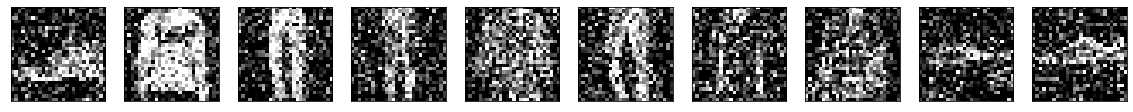

 Images generated by autoencoder model


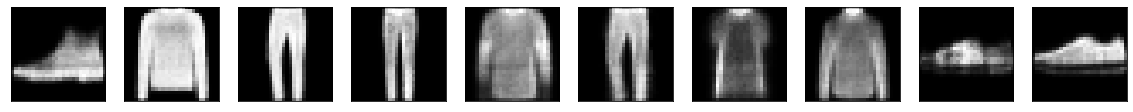

 Oringial images


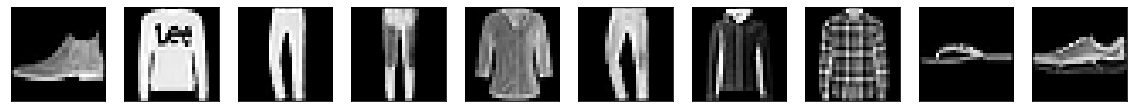

In [ ]:
# Plotting the noise test data
print(" Images after adding noise\n","="*26)
plot_images(N=10, image_array=X_test_noise, reshape=True)
print(" Images generated by autoencoder model\n","="*38)
plot_images(N=10, image_array=reconstructed_images, reshape=True)
print(" Oringial images\n","="*16)
plot_images(N=10, image_array=X_test, reshape=True)

Let's recall what we have done until now. We first started by adding noise to the original images. The our denoising autoencoder model is trained using these noisy images. Finally, our model is able to reconstructed output images as close to the original images.

This shows that how powerful the autoencoders are.

## Conclusion

You can see how well the deep neural network architecture of autoencoder can remove noise from the input and successfully reconstruct the output images. You can see the output images reconstructed by autoencoders are very close to the original images.  

Instead of this simple deep neural network architecture, we can use CNN based architecture too. In CNN based architecture, Vanilla CNN similar to what we learned in moduleX will be used for encoder and for decoder Transposed Convolutions are used. You can read about it further from the link provided in the reference section.

## References

1. Blog - keras
  - https://blog.keras.io/building-autoencoders-in-keras.html